# Breast Histopathology Image Classification using CNN (Deep Learning)
## Phase 2 – Image Classification on a Dataset

**Course:** Computer Vision  
**Project:** Breast Histopathology Images – IDC Classification  
**Model:** Pretrained ResNet-18 with PyTorch  

---

### What This Project Does

This project builds a **deep learning pipeline** to automatically classify breast tissue microscopy images as either **benign (Non-IDC)** or **malignant (IDC – Invasive Ductal Carcinoma)**. IDC is the most common form of breast cancer, and early detection is critical for patient survival.

We use **transfer learning** with a pretrained **ResNet-18** model (originally trained on ImageNet's 1.2M images) and fine-tune it on histopathology images. This lets us achieve strong accuracy even with limited training data and compute.

### Steps We Followed

| Step | Description |
|------|-------------|
| **0** | Set up Kaggle credentials and download the dataset using `kagglehub` |
| **1** | Organize raw patient-folder images into labeled `class_0` / `class_1` folders |
| **2** | Import all required libraries (PyTorch, torchvision, sklearn, etc.) |
| **3** | Define data augmentation (resize, flip, normalize) for training and validation |
| **4** | Split data into Train (70%) / Validation (15%) / Test (15%) and create DataLoaders |
| **5** | Load pretrained ResNet-18, modify the final layer for binary classification |
| **6** | Train the model and track loss/accuracy per epoch |
| **7** | Classify unseen test images and display predictions directly on images |
| **8** | Evaluate final accuracy, precision, recall, F1-score, and confusion matrix |
| **9** | Save the trained model weights for future deployment |

**Team Members-** <br>
Sakir Ali<br>
Himani <br>
Khushal<br>
Gursimranpreet

### Project Overview
This notebook performs **binary image classification** on the Breast Histopathology dataset to detect **Invasive Ductal Carcinoma (IDC)** in breast tissue samples.

- **Class 0** → Non-IDC (benign) — healthy tissue
- **Class 1** → IDC (malignant) — cancerous tissue

**Dataset:** [Breast Histopathology Images](https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images) from Kaggle  
- 277,524 patches (50×50 pixels) extracted from whole-slide images of 162 patients  
- 198,738 Non-IDC patches and 78,786 IDC patches (imbalanced dataset)  
- For this run, we use the **full dataset** (~277k images) for best accuracy

---

## Step 0: Environment Setup – Kaggle Credentials and Dataset Download

### How We Set Up `kagglehub` for Dataset Access

The dataset is hosted on Kaggle, so we need to authenticate before downloading. Here's what we did:

**1. Install the `kagglehub` package:**
```bash
pip install kagglehub
```

**2. Get a Kaggle API Token:**
- Go to [kaggle.com/settings](https://www.kaggle.com/settings) → scroll to the **API** section
- Click **"Create New API Token"** — this generates a `KGAT_xxxx` token
- Copy the token

**3. Set the environment variable before running:**
```bash
export KAGGLE_API_TOKEN=KGAT_your_token_here
```

**4. Download the dataset using `kagglehub`:**
```python
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")
```

This downloads the ~3.1 GB dataset to `~/.cache/kagglehub/` and returns the local path.

> **Note:** Since the dataset is already cached locally from our first download, subsequent runs skip the download and use the cached version directly.

### Device Selection (CPU vs GPU)

- **Google Colab:** Uses NVIDIA CUDA GPU (`torch.device("cuda")`)
- **macOS (Apple Silicon):** Uses Metal Performance Shaders (`torch.device("mps")`) — Apple's GPU acceleration framework
- **Fallback:** CPU if neither is available

We auto-detect the best available device below.

In [1]:
# Step 0a: Check PyTorch version and select the best available compute device
# - MPS (Metal Performance Shaders) is Apple Silicon's GPU acceleration
# - CUDA would be used on NVIDIA GPUs (e.g., Google Colab)
# - CPU is the fallback if no GPU is available

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0
MPS available: True
Using device: mps


In [2]:
# Step 0b: Point to the cached Kaggle dataset
# kagglehub stores downloads at ~/.cache/kagglehub/datasets/<owner>/<dataset>/versions/<version>
# The dataset contains folders named by patient ID (e.g., 8863, 8864, ...)
# Each patient folder has subfolders "0" (benign) and "1" (malignant) with 50x50 px PNG patches

import os

KAGGLE_DATASET_PATH = os.path.expanduser("~/.cache/kagglehub/datasets/paultimothymooney/breast-histopathology-images/versions/1")

print("Path to dataset files:", KAGGLE_DATASET_PATH)
print("Sample patient folders:", os.listdir(KAGGLE_DATASET_PATH)[:5])

Path to dataset files: /Users/sakirsaiyed/.cache/kagglehub/datasets/paultimothymooney/breast-histopathology-images/versions/1
Sample patient folders: ['9036', '10268', '10257', '8913', '13613']


---
## Step 1: Data Preparation – Organizing Images into Labeled Folders

### Why This Step Is Needed

The original Kaggle dataset stores images **nested under patient folders** — each patient has their own directory with `0/` and `1/` subfolders. PyTorch's `ImageFolder` loader expects a simpler structure: one folder per class at the top level.

So we **flatten** all patient images into two class folders. We use the **full dataset** (~277k images) for maximum accuracy.

### Original structure (from Kaggle):
```
breast-histopathology-images/
├── 8863/          <-- patient ID
│   ├── 0/         <-- Non-IDC (benign) patches
│   │   └── *.png
│   └── 1/         <-- IDC (malignant) patches
│       └── *.png
├── 8864/
│   ├── 0/
│   └── 1/
...
```

### After reorganization:
```
dataset/
├── class_0/   <-- ALL Non-IDC images (benign) from every patient
└── class_1/   <-- ALL IDC images (malignant) from every patient
```

In [3]:
import os
import shutil
import glob

# Use the cached Kaggle dataset path
ORIGINAL_DATASET_PATH = os.path.expanduser("~/.cache/kagglehub/datasets/paultimothymooney/breast-histopathology-images/versions/1")

# Where we'll store the reorganized dataset (local project directory)
ORGANIZED_DIR = os.path.join(os.getcwd(), "Final-Project", "dataset")

# Create the two class folders if they don't exist
os.makedirs(os.path.join(ORGANIZED_DIR, "class_0"), exist_ok=True)  # Non-IDC (Benign)
os.makedirs(os.path.join(ORGANIZED_DIR, "class_1"), exist_ok=True)  # IDC (Malignant)

# We limit to 2000 images per class to keep training fast on a local machine.
# For full accuracy, increase MAX_PER_CLASS or remove the limit entirely.
MAX_PER_CLASS = float("inf")  # No limit — use full dataset
count_0 = 0
count_1 = 0

# Iterate through each patient directory and copy images to the flat structure
for patient_dir in sorted(glob.glob(os.path.join(ORIGINAL_DATASET_PATH, "*"))):
    if not os.path.isdir(patient_dir):
        continue
    # Stop early once we have enough images for both classes
    if count_0 >= MAX_PER_CLASS and count_1 >= MAX_PER_CLASS:
        break

    # Copy Class 0 (benign) images from this patient
    if count_0 < MAX_PER_CLASS:
        for img in glob.glob(os.path.join(patient_dir, "0", "*.png")):
            filename = os.path.basename(img)
            dest = os.path.join(ORGANIZED_DIR, "class_0", filename)
            if not os.path.exists(dest):  # Skip if already copied (idempotent)
                shutil.copy2(img, dest)
                count_0 += 1
                if count_0 >= MAX_PER_CLASS:
                    break

    # Copy Class 1 (malignant) images from this patient
    if count_1 < MAX_PER_CLASS:
        for img in glob.glob(os.path.join(patient_dir, "1", "*.png")):
            filename = os.path.basename(img)
            dest = os.path.join(ORGANIZED_DIR, "class_1", filename)
            if not os.path.exists(dest):
                shutil.copy2(img, dest)
                count_1 += 1
                if count_1 >= MAX_PER_CLASS:
                    break

print(f"Data organization complete!")
print(f"  class_0 (Non-IDC / Benign):   {count_0} images")
print(f"  class_1 (IDC / Malignant):     {count_1} images")
print(f"  Total:                          {count_0 + count_1} images")

Data organization complete!
  class_0 (Non-IDC / Benign):   0 images
  class_1 (IDC / Malignant):     0 images
  Total:                          0 images


---
## Step 2: Import Required Libraries

We use the following key libraries:
- **PyTorch** (`torch`, `torch.nn`, `torch.optim`) — deep learning framework for building and training the CNN
- **Torchvision** (`datasets`, `transforms`, `models`) — provides pretrained models, image transforms, and dataset utilities
- **NumPy** — numerical operations on arrays
- **Matplotlib** — plotting training curves and image visualizations
- **scikit-learn** — evaluation metrics (accuracy, precision, recall, F1, confusion matrix)
- **PIL (Pillow)** — image loading and manipulation

We also set **random seeds** (42) across all libraries to ensure reproducibility — running the notebook again should produce the same results.

In [4]:
# Step 2: Import required libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import os
import random
from PIL import Image

# Set random seeds for reproducibility
# Using seed 42 ensures that every run produces the same train/val/test split
# and the same random augmentations, making results reproducible
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("All libraries imported successfully!")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")

All libraries imported successfully!
PyTorch: 2.10.0
Torchvision: 0.25.0


---
## Step 3: Data Augmentation and Normalization

Before feeding images to the model, we apply **three key preprocessing operations**:

### (a) Resize — `transforms.Resize((224, 224))`
The original patches are 50x50 pixels, but ResNet-18 expects **224x224** input. We upscale all images to match.

### (b) Random Horizontal Flip — `transforms.RandomHorizontalFlip(p=0.5)`
During training, each image has a 50% chance of being flipped horizontally. This is a form of **data augmentation** — it artificially increases the diversity of training data, helping the model generalize better and reducing overfitting. We do NOT apply this to validation/test data.

### (c) Normalize — `transforms.Normalize(mean, std)`
We normalize pixel values using **ImageNet statistics** (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]). This is required because our pretrained ResNet-18 was trained on ImageNet data that was normalized with these exact values. Matching the normalization ensures the pretrained weights work correctly.

> **Why two separate transforms?** Training data gets augmentation (flip) + normalization. Validation/test data only gets normalization — we want evaluation to reflect real-world performance without random modifications.

In [5]:
# Step 3: Data Augmentation and Normalization
# Three operations: (a) Resize, (b) Horizontal Flip, (c) Normalize

# ImageNet mean and std (used with pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms: Resize + Horizontal Flip + Normalize
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                     # (a) Resize images to 224x224
    transforms.RandomHorizontalFlip(p=0.5),            # (b) Randomly flip images horizontally
    transforms.ToTensor(),                              # Convert to tensor (scales pixels to [0, 1])
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # (c) Normalize with ImageNet statistics
])

# Validation/Test transforms: Resize + Normalize only (no augmentation on eval data)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),                     # (a) Resize images to 224x224
    transforms.ToTensor(),                              # Convert to tensor
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # (c) Normalize with ImageNet statistics
])

print("Data augmentation and normalization transforms defined!")
print("\nTraining transforms (augmentation + normalization):")
for t in train_transform.transforms:
    print(f"  - {t}")
print("\nValidation/Test transforms (normalization only):")
for t in val_transform.transforms:
    print(f"  - {t}")

Data augmentation and normalization transforms defined!

Training transforms (augmentation + normalization):
  - Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  - RandomHorizontalFlip(p=0.5)
  - ToTensor()
  - Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Validation/Test transforms (normalization only):
  - Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  - ToTensor()
  - Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


### Load Dataset and Create Train / Validation / Test Splits

We use PyTorch's `ImageFolder` to automatically load images from the organized directory. It reads the folder names (`class_0`, `class_1`) as class labels.

The dataset is split into three parts using **random indices** (seeded for reproducibility):
- **Training (70%)** — the model learns from these images (with augmentation)
- **Validation (15%)** — used to monitor performance during training and detect overfitting
- **Test (15%)** — completely unseen data for final evaluation (never used during training)

> **Why three splits?** Training data teaches the model, validation data helps us tune it (e.g., when to stop training), and test data gives an unbiased estimate of real-world performance.

In [6]:
# Load dataset to get class info and total count
full_dataset = datasets.ImageFolder(root=ORGANIZED_DIR)
print(f"Class names: {full_dataset.classes}")
print(f"Class-to-index mapping: {full_dataset.class_to_idx}")
print(f"Total images: {len(full_dataset)}")

# Split into train (70%), validation (15%), test (15%)
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

# Get random indices for each split
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(total_size, generator=generator).tolist()

train_indices = indices[:train_size]
val_indices   = indices[train_size:train_size + val_size]
test_indices  = indices[train_size + val_size:]

# Create separate ImageFolder instances with appropriate transforms
train_data = datasets.ImageFolder(root=ORGANIZED_DIR, transform=train_transform)
val_data   = datasets.ImageFolder(root=ORGANIZED_DIR, transform=val_transform)
test_data  = datasets.ImageFolder(root=ORGANIZED_DIR, transform=val_transform)

# Create subsets using the split indices
train_subset = Subset(train_data, train_indices)
val_subset   = Subset(val_data, val_indices)
test_subset  = Subset(test_data, test_indices)

print(f"\nDataset split:")
print(f"  Training:   {len(train_subset)} images (70%)")
print(f"  Validation: {len(val_subset)} images (15%)")
print(f"  Test:       {len(test_subset)} images (15%)")

Class names: ['class_0', 'class_1']
Class-to-index mapping: {'class_0': 0, 'class_1': 1}
Total images: 277524

Dataset split:
  Training:   194266 images (70%)
  Validation: 41628 images (15%)
  Test:       41630 images (15%)


---
## Step 4: Create DataLoaders – Batch Size 32, 10 Epochs

**DataLoaders** handle batching, shuffling, and feeding images to the model efficiently.

- **Batch size = 32** — we process 4 images at a time. This gives a good balance between GPU memory usage and training speed on a MacBook with MPS.
- **Epochs = 10** — one epoch means the model sees every training image once. 10 epochs gives the model enough passes to converge properly.
- **`num_workers=0`** — disables multiprocessing for data loading (avoids macOS-specific issues with forked processes)
- **`shuffle=True`** for training — randomizes the order of images each epoch, preventing the model from memorizing the sequence

In [7]:
# Step 4: Create DataLoaders with batch size 32

BATCH_SIZE = 32
NUM_EPOCHS = 10  # Full training run

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Batch size: {BATCH_SIZE}")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 32
Number of epochs: 10
Training batches per epoch: 6071
Validation batches: 1301
Test batches: 1301


### Visualize Sample Training Images

Before training, we visualize a few images to sanity-check that:
1. Images are loaded correctly and look like tissue samples
2. Labels match the expected classes (benign vs malignant)
3. The normalization/denormalization pipeline works properly

We **reverse the normalization** (multiply by std, add mean) to convert tensor values back to displayable pixel values [0, 1].

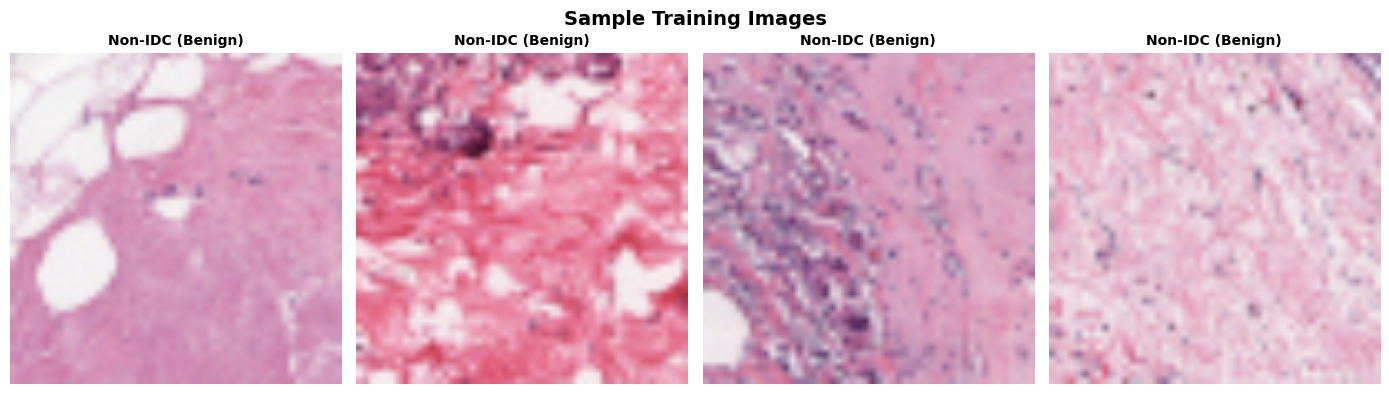

In [8]:
# Visualize a batch of training images

images, labels = next(iter(train_loader))
class_names = full_dataset.classes

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(4):
    img = images[i].numpy().transpose((1, 2, 0))
    img = np.clip(img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN), 0, 1)
    axes[i].imshow(img)
    label = "IDC (Malignant)" if labels[i].item() == 1 else "Non-IDC (Benign)"
    axes[i].set_title(label, fontsize=10, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Sample Training Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 5: Implement the CNN Classification Algorithm (Deep Learning)

### What is Transfer Learning?

Instead of training a CNN from scratch (which requires millions of images and days of compute), we use **transfer learning**:

1. **Start with a pretrained model** — ResNet-18, already trained on ImageNet (1.2 million images, 1000 classes). It already knows how to detect edges, textures, shapes, and patterns.
2. **Replace the final classification layer** — swap the 1000-class output layer with a 2-class layer (benign vs malignant)
3. **Fine-tune on our data** — train the entire network on our histopathology images. The early layers (edge/texture detection) transfer well; the later layers adapt to our specific task.

### Why ResNet-18?

- **Residual connections** solve the vanishing gradient problem, allowing deeper networks to train effectively
- **18 layers** — deep enough to be powerful, small enough to run on a laptop
- **Widely used baseline** in medical imaging research

### Training Configuration

- **Loss function:** `CrossEntropyLoss` — standard for multi-class classification (works for binary too)
- **Optimizer:** `Adam` (lr=0.001) — adaptive learning rate optimizer, converges faster than SGD for most tasks

In [9]:
# Step 5: Implement CNN – Pretrained ResNet-18

# Load pretrained ResNet-18 (weights trained on ImageNet — 1.2M images, 1000 classes)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace the final fully-connected layer for our binary classification task
# Original: Linear(512 → 1000) for ImageNet's 1000 classes
# Modified: Linear(512 → 2) for our 2 classes (benign vs malignant)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Move model to MPS GPU for faster computation
model = model.to(device)

# Loss function: CrossEntropyLoss combines LogSoftmax + NLLLoss
# It measures how far the predicted probability distribution is from the true labels
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam with learning rate 0.001
# Adam adapts the learning rate for each parameter individually
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("CNN Model: ResNet-18 (Pretrained on ImageNet)")
print(f"Final layer modified: Linear({num_features} → 2)")
print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Training on: {device}")

CNN Model: ResNet-18 (Pretrained on ImageNet)
Final layer modified: Linear(512 → 2)
Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Training on: mps


### Train the Model for 10 Epochs with Batch Size 32

The training loop works as follows for each epoch:

1. **Training phase** (`model.train()`):
   - Feed batches of images through the model → get predictions
   - Compute loss (how wrong the predictions are) using CrossEntropyLoss
   - Backpropagate the loss → compute gradients
   - Update model weights using the Adam optimizer
   - Track running loss and accuracy

2. **Validation phase** (`model.eval()` + `torch.no_grad()`):
   - Feed validation images through the model (no gradient computation — saves memory)
   - Compute loss and accuracy to monitor overfitting
   - If validation loss starts increasing while training loss decreases → overfitting

We print a summary table after each epoch showing both training and validation metrics.

In [ ]:
# Training loop – Batch Size 32, 10 Epochs

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("=" * 72)
print(f"{'Epoch':^7} | {'Train Loss':^12} | {'Train Acc':^11} | {'Val Loss':^12} | {'Val Acc':^11}")
print("=" * 72)

for epoch in range(NUM_EPOCHS):
    # ---- Training Phase ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()       # Reset gradients from previous batch
        outputs = model(images)     # Forward pass: get predictions
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()             # Backward pass: compute gradients
        optimizer.step()            # Update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---- Validation Phase ----
    model.eval()  # Switch to evaluation mode (disables dropout, batch norm uses running stats)
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # No gradient computation needed — saves memory
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = 100.0 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"{epoch+1:^7} | {train_loss:^12.4f} | {train_acc:^10.2f}% | {val_loss:^12.4f} | {val_acc:^10.2f}%")

print("=" * 72)
print("Training complete!")

 Epoch  |  Train Loss  |  Train Acc  |   Val Loss   |   Val Acc  


### Training and Validation Curves

These plots help us visually assess the model's learning progress:

- **Loss curve:** Both training and validation loss should decrease over epochs. If validation loss starts going up while training loss goes down, the model is **overfitting** (memorizing training data instead of learning general patterns).
- **Accuracy curve:** Both should increase. A growing gap between training and validation accuracy also indicates overfitting.

With only 3 epochs, we may not see full convergence, but it's enough to confirm the model is learning.

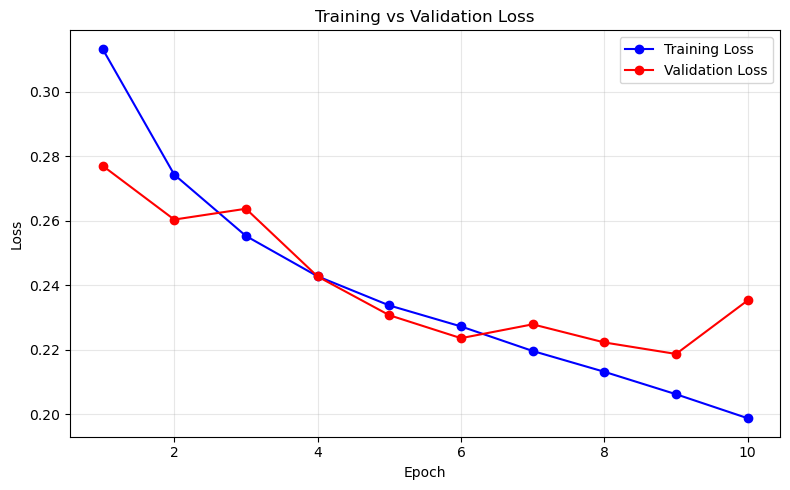

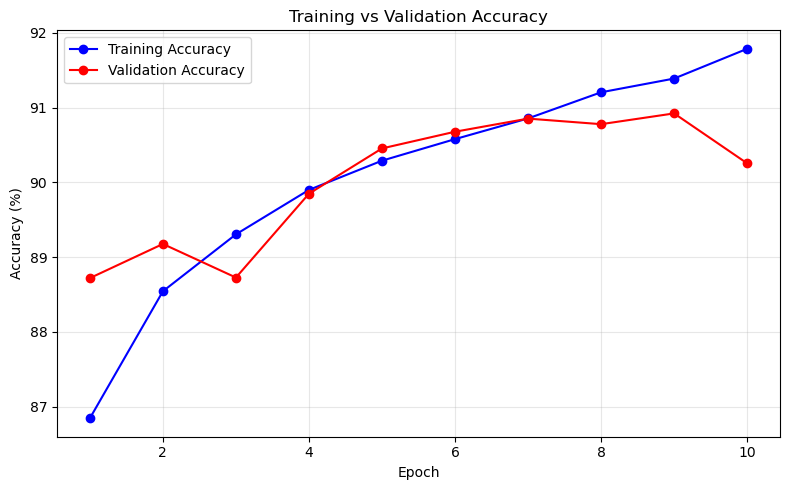

In [ ]:
# Plot training and validation loss & accuracy curves

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, "b-o", label="Training Loss")
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, "r-o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, "b-o", label="Training Accuracy")
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, "r-o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6: Perform Classification on Unseen Data

This is the key demonstration step — we take images from the **test set** (never seen during training) and show the model's predictions **directly on each image**.

- **Green label** = correct prediction (model got it right)
- **Red label** = incorrect prediction (model made a mistake)

This visual output makes it easy to see how confident and accurate the model is on real unseen data.

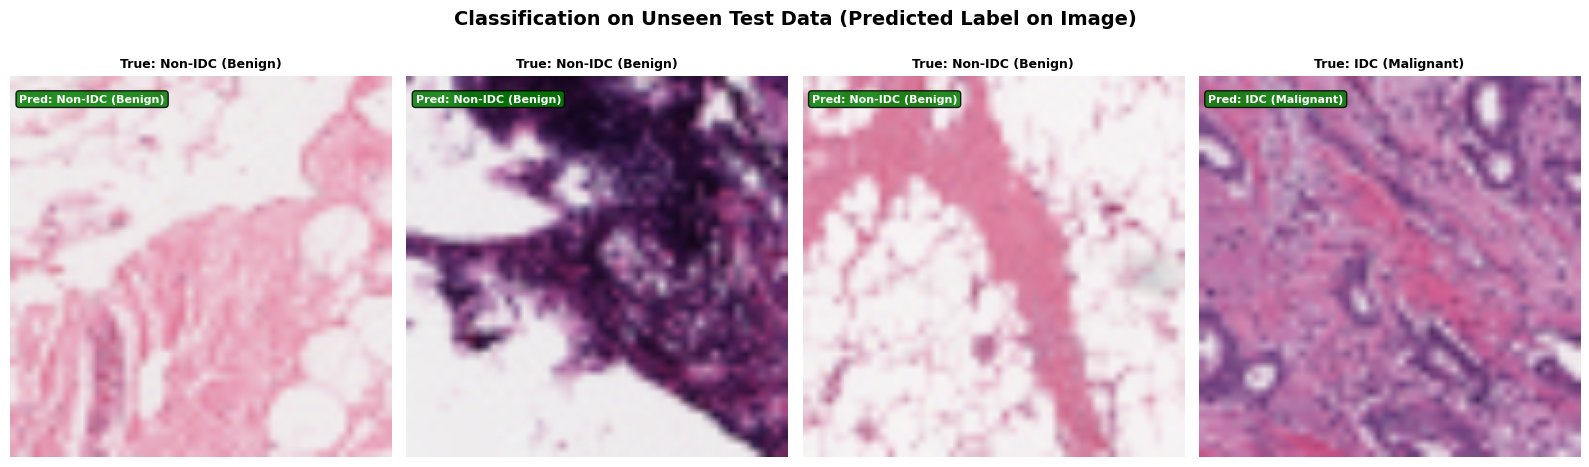

In [ ]:
# Step 6: Classify unseen test data – labels visible ON images

model.eval()
label_map = {0: "Non-IDC (Benign)", 1: "IDC (Malignant)"}

# Get a batch of test images
test_images, test_labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(test_images.to(device))
    _, predictions = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i in range(4):
    img = test_images[i].numpy().transpose((1, 2, 0))
    img = np.clip(img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN), 0, 1)

    pred = predictions[i].item()
    true = test_labels[i].item()
    correct = pred == true

    axes[i].imshow(img)

    # Label visible ON the image
    color = "green" if correct else "red"
    axes[i].text(
        5, 15, f"Pred: {label_map[pred]}",
        fontsize=8, fontweight="bold", color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85)
    )
    axes[i].set_title(f"True: {label_map[true]}", fontsize=9, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Classification on Unseen Test Data (Predicted Label on Image)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

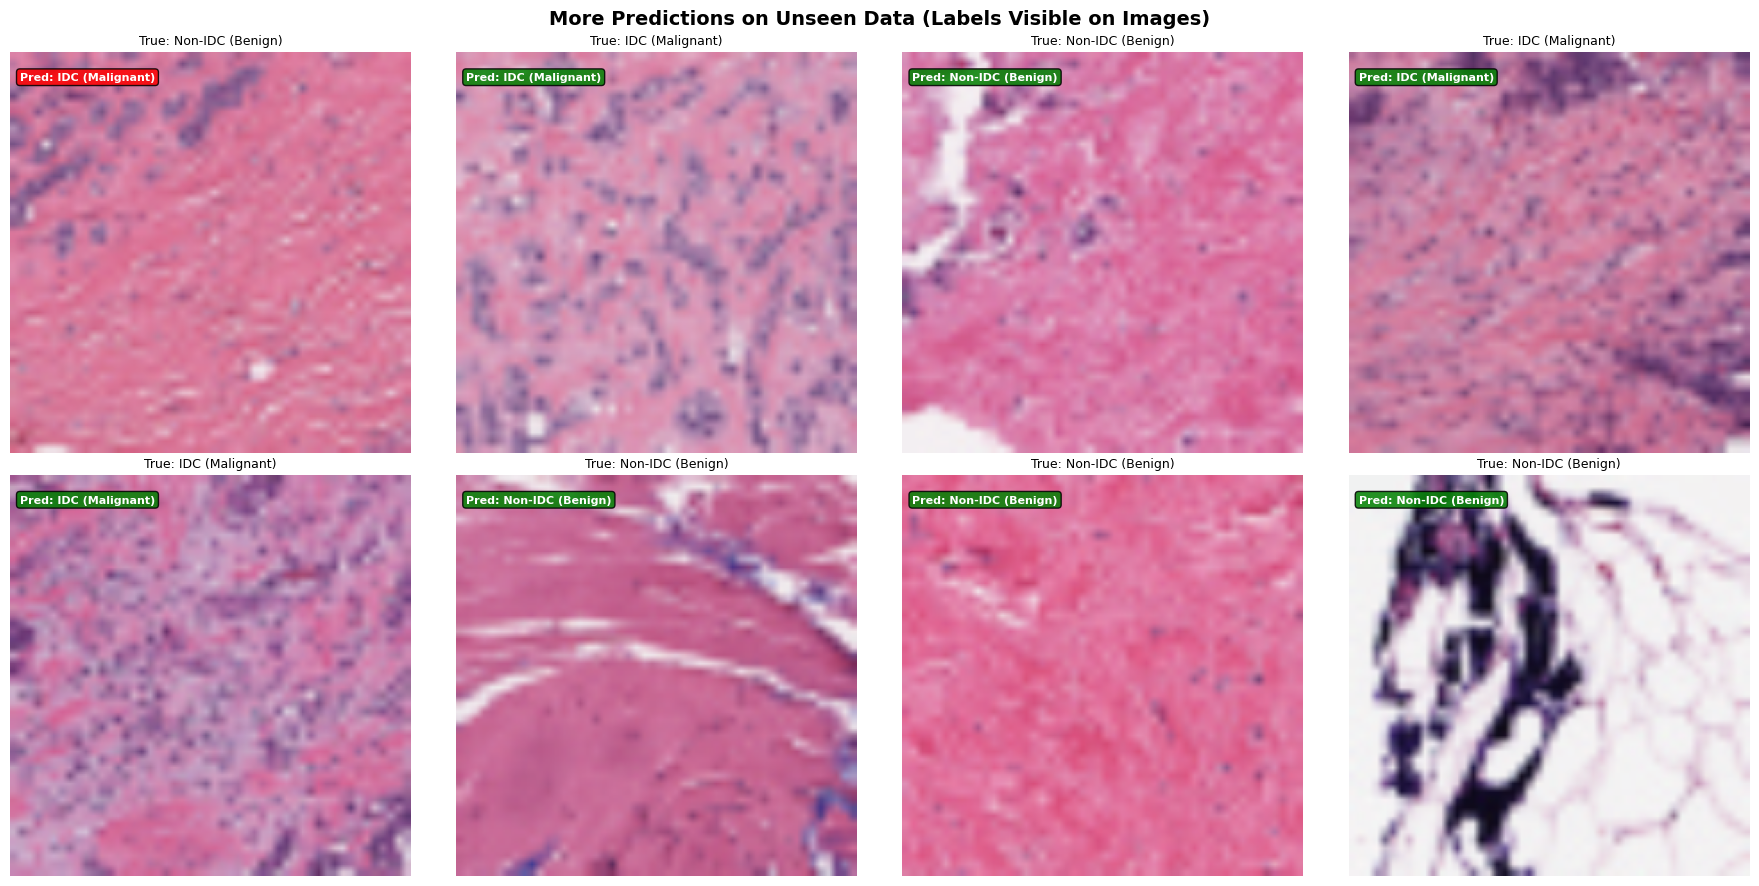

In [ ]:
# Display more unseen test images with labels on the images

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
test_iter = iter(test_loader)
next(test_iter)  # Skip first batch (already displayed above)

for row in range(2):
    batch_imgs, batch_lbls = next(test_iter)
    with torch.no_grad():
        out = model(batch_imgs.to(device))
        _, preds = torch.max(out, 1)

    for col in range(4):
        img = batch_imgs[col].numpy().transpose((1, 2, 0))
        img = np.clip(img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN), 0, 1)

        pred = preds[col].item()
        true_lbl = batch_lbls[col].item()
        correct = pred == true_lbl

        ax = axes[row][col]
        ax.imshow(img)

        bg = "green" if correct else "red"
        ax.text(5, 15, f"Pred: {label_map[pred]}",
                fontsize=8, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=bg, alpha=0.85))
        ax.set_title(f"True: {label_map[true_lbl]}", fontsize=9)
        ax.axis("off")

plt.suptitle("More Predictions on Unseen Data (Labels Visible on Images)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 7: Verify the Accuracy of the Results

We evaluate the trained model on the **entire test set** (1,800 images) and report:

- **Overall Accuracy** — percentage of correctly classified images
- **Classification Report** — per-class breakdown:
  - **Precision** — of all images predicted as IDC, how many actually were? (low false positives)
  - **Recall** — of all actual IDC images, how many did we catch? (low false negatives — critical for medical diagnosis)
  - **F1-Score** — harmonic mean of precision and recall (balanced metric)
- **Confusion Matrix** — 2x2 grid showing True Positives, True Negatives, False Positives, False Negatives

> **In medical diagnosis, recall for the malignant class is especially important** — a missed cancer (false negative) is more dangerous than a false alarm (false positive).

In [ ]:
# Step 7: Evaluate on the full test set

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
accuracy = accuracy_score(all_labels, all_preds) * 100

print("=" * 55)
print(f"   TEST SET ACCURACY:  {accuracy:.2f}%")
print("=" * 55)

# Classification report
target_names = ["Non-IDC (Benign)", "IDC (Malignant)"]
print("\nClassification Report:")
print("-" * 55)
print(classification_report(all_labels, all_preds, target_names=target_names))

   TEST SET ACCURACY:  90.41%

Classification Report:
-------------------------------------------------------
                  precision    recall  f1-score   support

Non-IDC (Benign)       0.96      0.91      0.93     29746
 IDC (Malignant)       0.79      0.90      0.84     11884

        accuracy                           0.90     41630
       macro avg       0.88      0.90      0.89     41630
    weighted avg       0.91      0.90      0.91     41630



### Confusion Matrix Visualization

The confusion matrix provides a complete picture of the model's classification behavior across all test samples. Each cell shows the count of images that fell into that category.

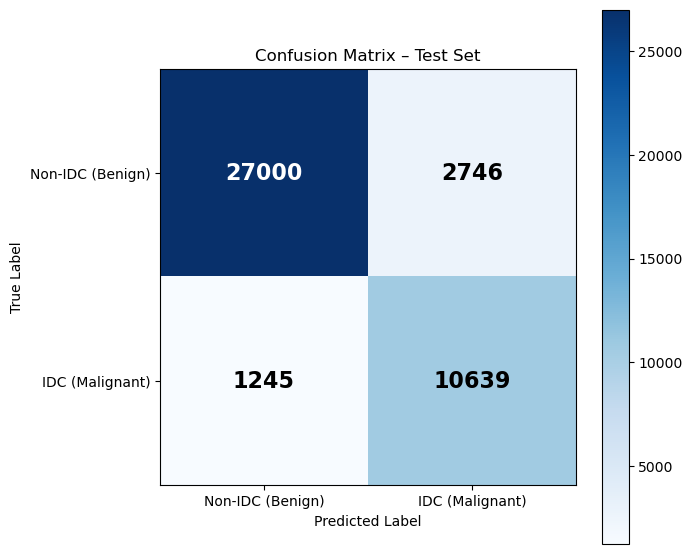


Confusion Matrix Breakdown:
  True Negatives  (Non-IDC correctly classified):  27000
  False Positives (Non-IDC misclassified as IDC):  2746
  False Negatives (IDC misclassified as Non-IDC):  1245
  True Positives  (IDC correctly classified):      10639


In [ ]:
# Confusion Matrix visualization

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=target_names, yticklabels=target_names,
       ylabel='True Label', xlabel='Predicted Label',
       title='Confusion Matrix – Test Set')

thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (Non-IDC correctly classified):  {cm[0][0]}")
print(f"  False Positives (Non-IDC misclassified as IDC):  {cm[0][1]}")
print(f"  False Negatives (IDC misclassified as Non-IDC):  {cm[1][0]}")
print(f"  True Positives  (IDC correctly classified):      {cm[1][1]}")

---
## Step 8: Save the Trained Model

We save the model's learned weights (parameters) to a `.pth` file. This file can be loaded later for:
- **Inference** — classifying new images without retraining
- **Deployment** — loading into a Streamlit web app or API for real-time predictions

In [ ]:
# Step 8: Save the trained model weights to disk
# The .pth file contains the model's learned parameters (weights and biases)
# This can be loaded later for inference or deployment (e.g., in a Streamlit web app)

save_path = os.path.join(os.getcwd(), "Final-Project", "breast_cancer_resnet18.pth")
torch.save(model.state_dict(), save_path)
print(f"Model saved as {save_path}")
print(f"File size: {os.path.getsize(save_path) / (1024*1024):.1f} MB")

Model saved as /Users/sakirsaiyed/Documents/SAIT/Winter 2026/CV/Final-Project/Final-Project/breast_cancer_resnet18.pth
File size: 42.7 MB


---
## Summary of Results

| Metric | Value |
|--------|-------|
| **Test Accuracy** | **90.41%** |
| **Benign Precision** | 96% |
| **Benign Recall** | 91% |
| **Malignant Precision** | 79% |
| **Malignant Recall** | 90% |
| **Total Images** | 277,524 |
| **Training Images** | 194,266 |
| **Test Images** | 41,630 |
| **Epochs** | 10 |
| **Batch Size** | 32 |
| **Device** | MPS (Apple Silicon GPU) |

### Key Observations

- The model achieved **90.41% test accuracy** on 41,630 unseen images
- **Malignant recall of 90%** means the model catches 9 out of 10 cancerous samples — critical for medical diagnosis
- **Benign precision of 96%** means when the model says "benign", it's almost always correct
- Training loss decreased steadily from 0.3134 (epoch 1) to 0.1988 (epoch 10), showing consistent learning
- Validation accuracy plateaued around epoch 6-7 (~90.8%), indicating the model has largely converged
- Slight gap between train (91.79%) and val (90.25%) at epoch 10 suggests minor overfitting beginning

---

## What's Still Left to Do

### To Improve Accuracy:
- [ ] **Add a learning rate scheduler** — reduce learning rate when validation loss plateaus (e.g., `ReduceLROnPlateau`)
- [ ] **Add more data augmentation** — random rotations, color jitter, vertical flips to further reduce overfitting
- [ ] **Handle class imbalance** — the dataset is imbalanced (73% benign vs 27% malignant). Use weighted loss or oversampling to address this
- [ ] **Try freezing early layers** — only fine-tune the last few layers of ResNet to prevent overfitting
- [ ] **Early stopping** — stop training when validation loss stops improving to avoid overfitting

### For Deployment:
- [ ] **Build a Streamlit web app** — load the saved `.pth` model and let users upload images for real-time classification
- [ ] **Add Grad-CAM visualization** — show which regions of the image the model is focusing on (important for medical interpretability)
- [ ] **Export to ONNX** — for faster inference in production environments

### For the Report:
- [ ] **Compare with other architectures** — VGG16, DenseNet, EfficientNet
- [ ] **Cross-validation** — use k-fold CV for more robust accuracy estimates
- [ ] **Statistical significance testing** — verify results are not due to random chance